In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate
from helper import *

In [22]:
mu_sun= 1.327e11 ## km^3/s^2  
mu_earth= 3.986e5 ## km^3/s^2  # 3.986e5
mu_mars= 4.2830e4 ## km^3/s^2

SOI_earth = 923502.24 # km
SOI_mars = 577723.87 # km

D_mars = 2.279e8
D_earth = 1.496e8

r_LEO = 463
R_LEO = 6378.2 + r_LEO

w_earth = 1.99177621e-7 # rad/s
w_mars = 1.05850987e-7 # rad/s

r_LMO = 200
R_LMO = 3397.0 + r_LMO

## Geocentric Phase

Positions relative to Earth unless specified

In [23]:
thetaPE0 = np.deg2rad(90)
deltaV_LEO = 0
init_phase = np.deg2rad(30)

In [24]:
rPEx0 = R_LEO*np.cos(thetaPE0) # thetaPE0 to be perscribed
rPEy0 = R_LEO*np.sin(thetaPE0) # thetaPE0 to be perscribed

vPEx0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.sin(thetaPE0)
vPEy0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.cos(thetaPE0)

y0 = np.array([rPEx0, rPEy0, vPEx0, vPEy0])
print(y0)

[ 4.18902684e-13  6.84120000e+03 -7.63312727e+00 -4.67394244e-16]


In [25]:
def four_body_ODE_geo( t, state , init_phase): # init phase in radians 
    rPEx, rPEy, vPEx, vPEy = state 
    rPE = np.array([rPEx, rPEy])
    rPE_norm = np.linalg.norm(rPE)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])
    r_earth_norm = np.linalg.norm(r_earth)

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    # Relative vectors (Spacecraft to Planet)
    rP = rPE + r_earth 
    rP_norm = np.linalg.norm(rP)

    rPM = rP - r_mars       # I think
    rPM_norm = np.linalg.norm(rPM)

    aPEx = (-((mu_sun / (rP_norm**3)) * (rPEx + rx_earth))
    - ((mu_earth / (rPE_norm**3)) * (rPEx))
    - ((mu_mars / (rPM_norm**3)) * (rPEx + rx_earth - rx_mars))
    + ((mu_sun / (r_earth_norm**3)) * (rx_earth)))

    # aPEx = - ((mu_earth / (rPE_norm**3)) * (rPEx))
#     print(aPEx)
#     print(f"""
# {-((mu_sun / (rP_norm**3)) * (rPEx + rx_earth))}
# {- ((mu_earth / (rPE_norm**3)) * (rPEx))}
# {- ((mu_mars / (rPM_norm**3)) * (rPEx + rx_earth - rx_mars))}
# {+ (mu_sun / (r_earth_norm**3)) * (rx_earth)}
# """)

    aPEy = (-((mu_sun / (rP_norm**3)) * (rPEy + ry_earth)) 
    - ((mu_earth / (rPE_norm**3)) * (rPEy)) 
    - ((mu_mars / (rPM_norm**3)) * (rPEy + ry_earth - ry_mars)) 
    + ((mu_sun / (r_earth_norm**3)) * (ry_earth)))

    # aPEy = - ((mu_earth / (rPE_norm**3)) * (rPEy))


#     print(f"""
# {-((mu_sun / (rP_norm**3)) * (rPEy + ry_earth))}
# {- ((mu_earth / (rPE_norm**3)) * (rPEy))}
# {- ((mu_mars / (rPM_norm**3)) * (rPEy + ry_earth - ry_mars))}
# {+ (mu_sun / (r_earth_norm**3)) * (ry_earth)}
# """)
    return [vPEx, vPEy, aPEx, aPEy]

state = four_body_ODE_geo(0,y0 , init_phase)
print(state)



[np.float64(-7.633127271041515), np.float64(-4.673942439982681e-16), np.float64(1.1033830438406979e-12), np.float64(-0.008516727149213813)]


In [26]:
a = -5.9292375875799524e-06 -0.0019043301658742881 + 1.084760734292471e-12 + 5.929358860705197e-06
print(a)

-0.0019043300435164022


In [27]:
thetaPE0 = 0
deltaV_LEO = 0
init_phase = np.deg2rad(30)
# R_LEO is rPE(0)

In [28]:
rPEx0 = R_LEO*np.cos(thetaPE0) # thetaPE0 to be perscribed
rPEy0 = R_LEO*np.sin(thetaPE0) # thetaPE0 to be perscribed

vPEx0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.sin(thetaPE0)
vPEy0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.cos(thetaPE0)

y0 = (rPEx0, rPEy0, vPEx0, vPEy0)
print(y0)

(np.float64(6841.2), np.float64(0.0), np.float64(-0.0), np.float64(-7.633127271041515))


In [29]:
# t = np.linspace(1,100000, 10000)
# sol = integrate.odeint(four_body_ODE_geo,y0 = y0 , t = t, args=(init_phase,))

# rPEx_sol = sol.T[0]
# rPEy_sol = sol.T[1]
# vPEx_sol = sol.T[2]
# vPEy_sol = sol.T[3]

In [30]:
init_phase = 182.928 - np.rad2deg(w_mars*(60*60*24*264.430))
print(init_phase)

44.36668005530447


In [31]:
# timespan 
tspan = 100*60.0

# timestep 
dt = 10

# total steps
n_steps = int(np.ceil(tspan/dt))
step = 1

# Parameters
thetaPE0 = np.rad2deg(299.474)
deltaV_LEO = 3.555746
init_phase = np.deg2rad(init_phase)

# initial conditions
rPEx0 = R_LEO*np.cos(thetaPE0) # thetaPE0 to be perscribed
rPEy0 = R_LEO*np.sin(thetaPE0) # thetaPE0 to be perscribed

vPEx0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.sin(thetaPE0)
vPEy0 = (np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.cos(thetaPE0)
print(np.sqrt(mu_earth/R_LEO) * np.sin(thetaPE0))
print(vPEy0)

y0 =np.array([rPEx0, rPEy0, vPEx0, vPEy0], None)
t0 = 0

ys = y0
ts = [0]
step = 0
print(y0)
print(ts)



-5.3833944683492
7.932257346955985
[ 4850.01104646 -4824.87412159     7.89114557     7.93225735]
[0]


In [32]:
solver = integrate.ode(four_body_ODE_geo)
solver.set_integrator("zvode") #  
solver.set_initial_value(y0, t0)
solver.set_f_params(init_phase)

while solver.successful():
    solver.integrate(solver.t + dt)
    ys = np.vstack((ys,solver.y))
    ts = np.vstack((ts, solver.t))
    step += 1
    # print(ys[step,:2 ])
    # print(solver.get_return_code())
    if np.linalg.norm(ys[step,:2]) > SOI_earth:
        break

print(ys)
print(ts)





[[ 4.85001105e+03+0.j -4.82487412e+03+0.j  7.89114557e+00+0.j
   7.93225735e+00+0.j]
 [ 4.92861777e+03+0.j -4.74525252e+03+0.j  7.83028152e+00+0.j
   7.99182115e+00+0.j]
 [ 5.00661223e+03+0.j -4.66504083e+03+0.j  7.76846953e+00+0.j
   8.05036751e+00+0.j]
 ...
 [-2.25247485e+05+0.j  8.95570559e+05+0.j -8.33657943e-01+0.j
   2.96649852e+00+0.j]
 [-2.25255821e+05+0.j  8.95600224e+05+0.j -8.33656920e-01+0.j
   2.96649362e+00+0.j]
 [-2.25264158e+05+0.j  8.95629889e+05+0.j -8.33655897e-01+0.j
   2.96648872e+00+0.j]]
[[0.0000e+00]
 [1.0000e+01]
 [2.0000e+01]
 ...
 [2.7276e+05]
 [2.7277e+05]
 [2.7278e+05]]


In [33]:
ys

array([[ 4.85001105e+03+0.j, -4.82487412e+03+0.j,  7.89114557e+00+0.j,
         7.93225735e+00+0.j],
       [ 4.92861777e+03+0.j, -4.74525252e+03+0.j,  7.83028152e+00+0.j,
         7.99182115e+00+0.j],
       [ 5.00661223e+03+0.j, -4.66504083e+03+0.j,  7.76846953e+00+0.j,
         8.05036751e+00+0.j],
       ...,
       [-2.25247485e+05+0.j,  8.95570559e+05+0.j, -8.33657943e-01+0.j,
         2.96649852e+00+0.j],
       [-2.25255821e+05+0.j,  8.95600224e+05+0.j, -8.33656920e-01+0.j,
         2.96649362e+00+0.j],
       [-2.25264158e+05+0.j,  8.95629889e+05+0.j, -8.33655897e-01+0.j,
         2.96648872e+00+0.j]], shape=(27279, 4))

In [34]:
rs = ys[:,:2]
rsx = rs.T[0]
rsy = rs.T[1]

f:\project\orbital_trajectories\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
f:\project\orbital_trajectories\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


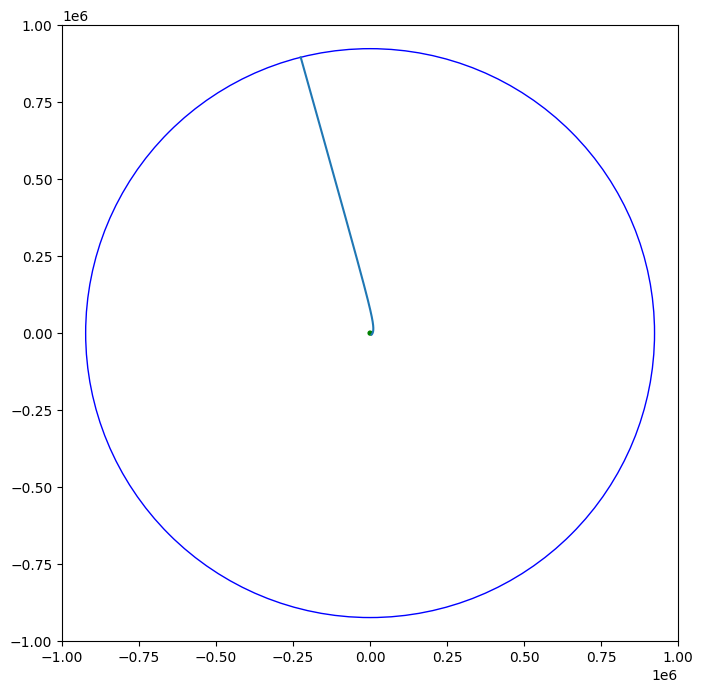

In [35]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(-1e6,+1e6)
plt.ylim(-1e6,+1e6)

plt.plot(rsx, rsy)
earth = plt.Circle((0,0), 6378.2, color = "g")
earthSOI = plt.Circle((0, 0), SOI_earth, color='b', fill=False)

ax.add_patch(earth)
ax.add_patch(earthSOI)

plt.show()

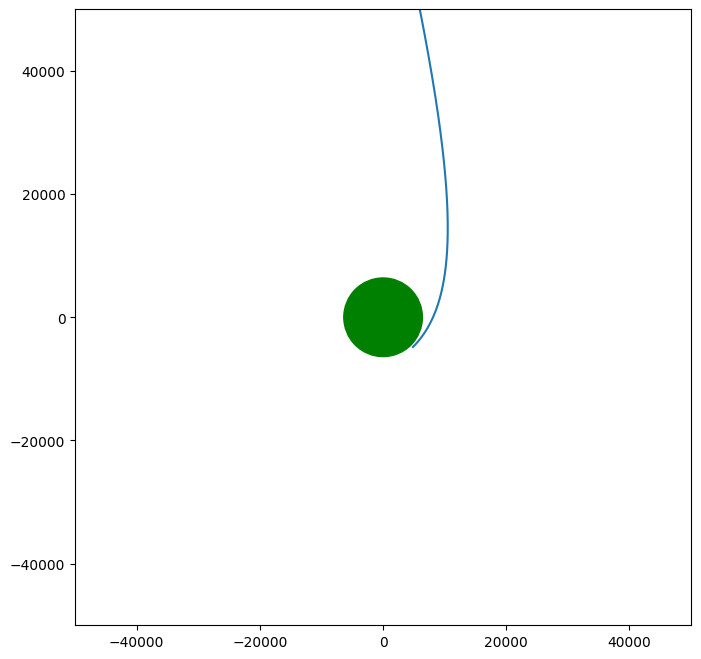

In [36]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(-5e4,+5e4)
plt.ylim(-5e4,+5e4)

plt.plot(rsx, rsy)
earth = plt.Circle((0,0), 6378.2, color = "g")
earthSOI = plt.Circle((0, 0), SOI_earth, color='b', fill=False)

ax.add_patch(earth)
ax.add_patch(earthSOI)

plt.show()

## Heliocentric Phase   


In [37]:
def four_body_ODE_helio(t, state, init_phase): # init phase in radians 
    rPx, rPy, vPx, vPy = state 
    rP = np.array([rPx, rPy])
    rP_norm = np.linalg.norm(rP)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    rPM = rP - r_mars       # I think
    rPM_norm = np.linalg.norm(rPM)

    rPE = rP = r_earth
    rPE_norm = np.linalg.norm(rPE)

    aPx = (-((mu_sun / (rP_norm**3)) * (rPx))
    - ((mu_earth / (rPE_norm**3)) * (rPx - rx_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPx - rx_mars)))

    aPy = (-((mu_sun / (rP_norm**3)) * (rPy))
    - ((mu_earth / (rPE_norm**3)) * (rPy - ry_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPy - ry_mars)))

    return [vPx, vPy, aPx, aPy]

four_body_ODE_helio(0.5,[10,10,10,10], 10)

[10, 10, np.float64(-469165349.3172742), np.float64(-469165349.3172742)]

In [38]:
def get_rPM_norm(rP, t):
    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])
    rPM = rP - r_mars       # I think
    rPM_norm = np.linalg.norm(rPM)
    return rPM_norm

In [39]:
y1PE = ys[-1]
t1 = ts[-1]

print(y1PE, t1)

[-2.25264158e+05+0.j  8.95629889e+05+0.j -8.33655897e-01+0.j
  2.96648872e+00+0.j] [272780.]


In [40]:
rx_earth1 = D_earth*np.cos(w_earth*t1)
ry_earth1 = D_earth*np.sin(w_earth*t1)

vx_earth1 = -w_earth*D_earth*np.sin(w_earth*t1)
vy_earth1 = w_earth*D_earth*np.cos(w_earth*t1)

rPEx1, rPEy1, vPEx1, vPEy1 = y1PE

# get_rPM_norm([rPEx1,rPEy1], t1)

In [41]:
# timespan 
tspan = 100*60.0

# timestep 
dt = 60*10

# total steps
n_steps = int(np.ceil(tspan/dt))
step = 1

# # Parameters
# thetaPE0 = np.rad2deg(68)
# deltaV_LEO = 3.552
# init_phase = np.deg2rad(30)

# initial conditions
rPx1 = rx_earth1 + rPEx1 
rPy1 = ry_earth1 + rPEy1 

vPx1 = vx_earth1 + vPEx1 
vPy1 = vy_earth1 + vPEy1 


y1 =np.array([rPx1[0].real, rPy1[0].real, vPx1[0].real, vPy1[0].real])
t1 = t1

ys = y1
ts = t1
step = 0
print(y1)
print(t1)


[ 1.49153986e+08  9.01964964e+06 -2.45177882e+00  3.27194923e+01]
[272780.]


In [42]:
solver = integrate.ode(four_body_ODE_helio)
solver.set_integrator("zvode") #  
solver.set_initial_value(y1, t1[0])
solver.set_f_params(init_phase)

while solver.successful() and step < 100000:
    solver.integrate(solver.t + dt)
    ys = np.vstack((ys,solver.y))
    ts = np.vstack((ts, solver.t))
    step += 1
    # print(ys[step,:2 ])
    if get_rPM_norm([solver.y[0],solver.y[1]], solver.t) < SOI_mars:
        break

print(ys)
print(ts)


[[ 1.49153986e+08+0.j  9.01964964e+06+0.j -2.45177882e+00+0.j
   3.27194923e+01+0.j]
 [ 1.49152511e+08+0.j  9.03928113e+06+0.j -2.45533818e+00+0.j
   3.27192764e+01+0.j]
 [ 1.49151037e+08+0.j  9.05891261e+06+0.j -2.45889754e+00+0.j
   3.27190603e+01+0.j]
 ...
 [-1.72409695e+08+0.j  1.25918162e+08+0.j -1.67999182e+01+0.j
  -1.61551431e+01+0.j]
 [-1.72419774e+08+0.j  1.25908469e+08+0.j -1.67985075e+01+0.j
  -1.61561733e+01+0.j]
 [-1.72429853e+08+0.j  1.25898775e+08+0.j -1.67970968e+01+0.j
  -1.61572034e+01+0.j]]
[[  272780.]
 [  273380.]
 [  273980.]
 ...
 [60271580.]
 [60272180.]
 [60272780.]]


In [50]:
rs = ys[:,:2]
rsx = rs.T[0]
rsy = rs.T[1]

t2 = ts[-1]
t2 = 264.43*(60*60*24)

In [51]:
# Pos of Earth at t1
rx_earth1 = D_earth*np.cos(w_earth*t1)
ry_earth1 = D_earth*np.sin(w_earth*t1)

# Pos of Mars at t1
rx_mars1 = D_mars*np.cos(w_mars*t1 + init_phase)
ry_mars1 = D_mars*np.sin(w_mars*t1 + init_phase)

# Pos of Mars at t2
rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

print((w_mars*t2))
# Pos of Earth at t2 
rx_earth2 = D_earth*np.cos(w_earth*t2)
ry_earth2 = D_earth*np.sin(w_earth*t2)


2.4183512489442243


f:\project\orbital_trajectories\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
f:\project\orbital_trajectories\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


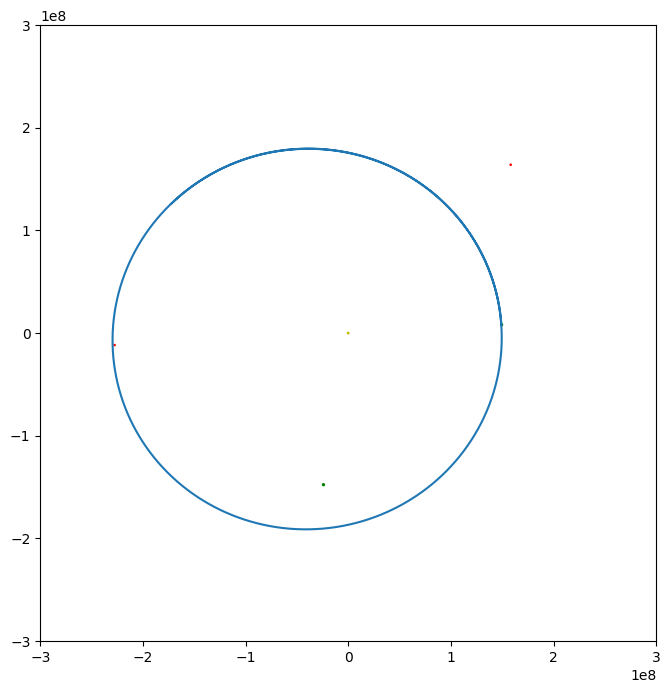

In [52]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(-3e8,+3e8)
plt.ylim(-3e8,+3e8)

plt.plot(rsx, rsy)

earth1SOI = plt.Circle((rx_earth1[0], ry_earth1[0]), SOI_earth*1, color='g', fill=False)
earth2SOI = plt.Circle((rx_earth2, ry_earth2), SOI_earth*1, color='g', fill=True)

mars1SOI = plt.Circle((rx_mars1[0], ry_mars1[0]), SOI_mars*1, color='r', fill=False)
mars2SOI = plt.Circle((rx_mars2, ry_mars2), SOI_mars*1, color='r', fill=True)

Sun = plt.Circle((0, 0), 696340*1, color='y', fill=True)

ax.add_patch(earth1SOI)
ax.add_patch(earth2SOI)

ax.add_patch(mars1SOI)
ax.add_patch(mars2SOI)
ax.add_patch(Sun)

plt.show()

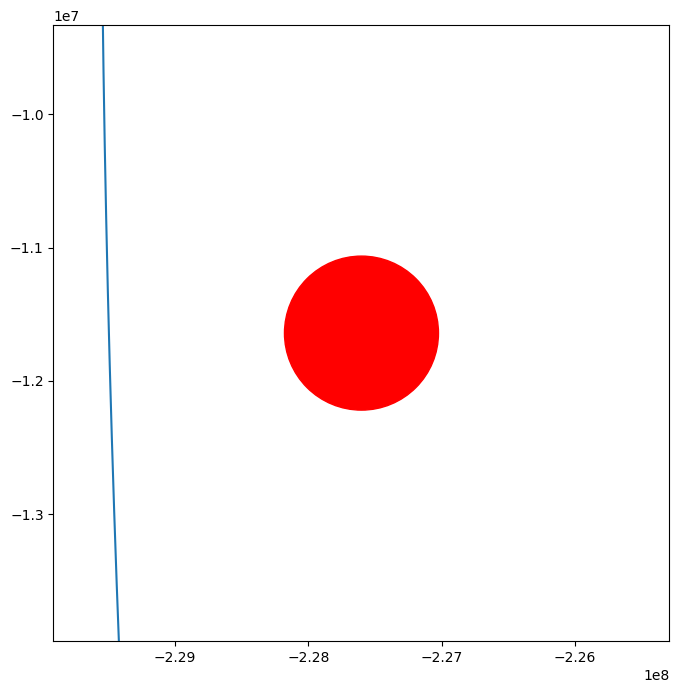

In [53]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(rx_mars2 - SOI_mars*4,rx_mars2 + SOI_mars*4)
plt.ylim(ry_mars2 - SOI_mars*4,ry_mars2 + SOI_mars*4)

plt.plot(rsx, rsy)

earth1SOI = plt.Circle((rx_earth1[0], ry_earth1[0]), SOI_earth*1, color='g', fill=False)
earth2SOI = plt.Circle((rx_earth2, ry_earth2), SOI_earth*1, color='g', fill=True)

mars1SOI = plt.Circle((rx_mars1[0], ry_mars1[0]), SOI_mars*1, color='r', fill=False)
mars2SOI = plt.Circle((rx_mars2, ry_mars2), SOI_mars*1, color='r', fill=True)

Sun = plt.Circle((0, 0), 696340*1, color='y', fill=True)

ax.add_patch(earth1SOI)
ax.add_patch(earth2SOI)

ax.add_patch(mars1SOI)
ax.add_patch(mars2SOI)
ax.add_patch(Sun)

plt.show()

## Marscentric 

In [ ]:
def four_body_ODE_mars( t, state, init_phase): # init phase in radians 
    rPMx, rPMy, vPMx, vPMy = state 
    rPM = np.array([rPMx, rPMy])
    rPM_norm = np.linalg.norm(rPM)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])
    r_mars_norm = np.linalg.norm(r_mars)

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    rPE = rP = r_earth
    rPE_norm = np.linalg.norm(rPE)

    rP = rPE + r_earth 
    rP_norm = np.linalg.norm(rP)

    aPMx = -((mu_sun / (rP_norm**3)) * (rPMx + rx_mars))
    - ((mu_earth / (rPE_norm**3)) * (rPMx + rx_mars - rx_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPMx))
    + ((mu_sun / (r_mars_norm**3)) * (rx_mars))

    aPMy = -((mu_sun / (rP_norm**3)) * (rPMy + ry_mars))
    - ((mu_earth / (rPE_norm**3)) * (rPMy + ry_mars - ry_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPMy))
    + ((mu_sun / (r_mars_norm**3)) * (ry_mars))

    return [vPMx, vPMy, aPMx, aPMy]

four_body_ODE_mars([10,10,10,10],0.5, 10)

[10, 10, np.float64(9.473913779051102e-07), np.float64(6.142515115038357e-07)]

In [54]:
y2 = ys[-1]
t2 = ts[-1]

print(y2, t2)

[-1.72429853e+08+0.j  1.25898775e+08+0.j -1.67970968e+01+0.j
 -1.61572034e+01+0.j] [60272780.]


In [57]:
rPx2, rPy2, vPx2, vPy2 = y2


In [58]:
rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

vx_mars2 = -w_mars*D_mars*np.sin(w_mars*t2 + init_phase)
vy_mars2 = w_mars*D_mars*np.cos(w_mars*t2 + init_phase)

In [59]:
# Initial Conditions
rPMx2 = rPx2 - rx_mars2
rPMy2 = rPy2 - ry_mars2

vPMx2 = vPx2 - vx_mars2
vPMy2 = vPy2 - vy_mars2